Step 1: Import Packages and Take a view of data

In [12]:
#Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Step 2: Initial EDA and data cleaning - Understand variables and clean data (missing, redundant, outlier data)

In [14]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [15]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [16]:
'''We notice that column names are not standard and in someplaces misspeled'''
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [17]:
# Rename the columns
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})
df0.columns # Column names changed

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [18]:
'''Checking for any missing value '''
df0.isna().sum() # No missing value found

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [19]:
'''Check for duplicate entries'''
df0.duplicated().sum() # That's 20% of the whole data.

3008

We found that more than 20% of the data is duplicated. Since most of the columns are continuous its highly unlikely
that two different employee have entered the same value for every column. Hence we decide to drop them.

In [20]:
'''Drop duplicates, and save dataframe to a new variable'''
df1 = df0.drop_duplicates(keep = "first")

df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


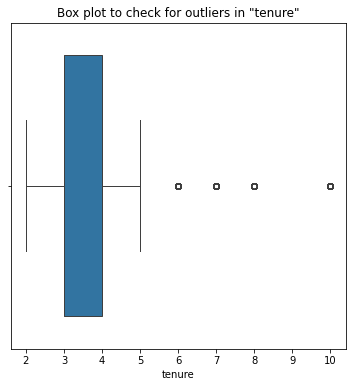

In [21]:
'''Check for outliers'''

plt.figure(figsize=(6,6))
plt.title("Box plot to check for outliers in \"tenure\"")
sns.boxplot(x=df1["tenure"])
plt.show()

Boxplot confirms that there are outliers in the column tenure and it might be useful to know how many rows contains outliers.

In [22]:
# Determining the number of rows containing outliers

# Value below which 25% of the data lies
percentile25 = df1["tenure"].quantile(0.25)

# Value below which 75% of the data lies
percentile75  = df1["tenure"].quantile(0.75)

# Find interquantile range
iqr = percentile75 - percentile25

# Define upper limit and lower limit for non-outlier values in "tenure"
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print(f"upper_limit = {upper_limit}")
print(f"lower_limit = {lower_limit}")

outliers = df1[(df1["tenure"] > upper_limit) | (df1["tenure"] < lower_limit)]

print(f"Number of outliers for column tenure is {len(outliers)}")

# This is a magic method to be able to export these variables to another notebook
%store upper_limit
%store lower_limit


upper_limit = 5.5
lower_limit = 1.5
Number of outliers for column tenure is 824
Stored 'upper_limit' (float64)
Stored 'lower_limit' (float64)


Saving updated and cleaned dataset as to further analyze it in Tableau

In [23]:
# df1.to_csv("HR_Attrition.csv")